### MODULE 0
**0.1: Simple Chat invoking**

**0.2: Human Message and AI Message**

**0.3: LangChain Core**

**0.4: LangChain Community**

**0.5: Search Tool (TAVILY Search API)**

- just for testing purpose to check our gemini model is working or not
- Chat models in langchain have a number of default response

**Stream**: SStream back chunks of the response

**Invoke**: Call the claim on an input
- Chat models take message as input. Messages have a role (that describes who is saying the message) and a content property

!pip install langchain-google-genai langchain-core

In [6]:
import os
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()

True

In [7]:
os.environ["GEMINI_API_KEY"] = os.getenv("GEMINI_API_KEY")
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.5
)

#### In this results, the AI message we get from the gemini model

In [8]:
results = llm.invoke("Hi! I am Moiz Ali Afzaal")
results

AIMessage(content="Hello Moiz Ali Afzaal! It's a pleasure to meet you. How can I assist you today?", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ea7c7-af71-7302-82c5-f8b751f1dd0f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 565, 'total_tokens': 576, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 541}})

#### Another method
- Where human sends a message

In [9]:
from langchain_core.messages import HumanMessage

#Creating a Human Message
msg = HumanMessage(content="what is the capital of Australia?", name="Moiz Ali Afzaal")

#Message List
messages = [msg]

#Invoke he model with a list of messages
results = llm.invoke(messages)
results

AIMessage(content='The capital of Australia is **Canberra**.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ea7cc-a176-77d1-97c0-aab04417d78a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 31, 'total_tokens': 39, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 22}})

#### Same but a little chaining method
- context awareness

In [15]:
!pip install tavily-python
!pip install langchain-community

^C


In [12]:
from langchain_core.messages import HumanMessage, AIMessage

messages = [
    HumanMessage(content="Hi! My name is Moiz Ali Afzaal", name="HumanMessage"),
    AIMessage(content="Hi! How can I help you?", name="AIMessage"),
    HumanMessage(content="What is the capital if Australia?", name="HumanMessage"),
    AIMessage(content="The capital of Australia is Canberra", name="AIMessage"),
    HumanMessage(content="What is my name?", name="HumanMessage")
]

results = llm.invoke(messages)
results

AIMessage(content='Your name is Moiz Ali Afzaal.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ea7d2-54e4-7ce0-87a7-11655318465d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 60, 'total_tokens': 102, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 50}})

In [13]:
results.content

'Your name is Moiz Ali Afzaal.'

### Search Tools
- We use Tavily for this purpose
- Tavily gives us some credits where can do some web research and design the agent in a way that can do realtime web-search

In [26]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults
from dotenv import load_dotenv
load_dotenv()

tavily_search = TavilySearchResults(max_results=2)
search_web = tavily_search.invoke("Is python, fastapi, langchain, langraph, mcp, docker are enough to build a strong saas application?")
search_web

[{'title': 'Best FastAPI posts of 2025 | daily.dev',
  'url': 'https://app.daily.dev/tags/fastapi/best-of/2025',
  'content': 'A comprehensive guide covering Docker fundamentals and building AI agents with Python. Starts with Docker basics including container creation, image building, and Docker Compose usage. Progresses through setting up FastAPI web applications, integrating databases, and ultimately implementing AI agents using Langchain and Langraph. Covers both local development with Docker containers and deployment strategies using services like Railway and Digital Ocean. Demonstrates how to use both managed LLM services and open-source AI models available through DockerHub.\n\nAvatar of dailydoseofds\n\nBuilding a Full-stack Agentic App [...] Avatar of tds\n\nHow to Build an AI Budget-Planning Optimizer for Your 2026 CAPEX Review: LangGraph, FastAPI, and n8n\n\nA comprehensive guide to building an AI-powered budget planning system that automates CAPEX portfolio optimization. The

### Module 01:
**State**

**Edges**

**Nodes**

**Graphs**

#### State:
State scehmas serves as the input schema for all Nodes and Edges in the graph.
- For now let's use the TypedDict class from python's typing module as our schema, which provides type hints for the keys

In [2]:
from typing_extensions import TypedDict

class LearningState(TypedDict):
    prompt: str

In [3]:
isb_state = LearningState(prompt="Hello, I'm Moiz From Islamabad")

In [4]:
print(isb_state)

{'prompt': "Hello, I'm Moiz From Islamabad"}


In [5]:
print(isb_state['prompt'])

Hello, I'm Moiz From Islamabad


In [6]:
print(isb_state['prompt'] + "and I am an AI Product Engineer") #we just added a new string to the existing prompt in the learning state. This is how we can update the learning state with new information.

Hello, I'm Moiz From Islamabadand I am an AI Product Engineer


In [7]:
print(type(isb_state))

<class 'dict'>


#### Nodes:
Nodes are functions
- Because the state is a TypedDict with schema as defined above, each node can access the key, graph_state with state['grah_state']
- Each node returns a new value of the state key graph_state
- By default, the new value returned by each node will override the prior state value

In [8]:
def node_1(state: LearningState) -> LearningState:
    print("Node 1: State", state)
    return {"prompt": state['prompt'] + "and I am an AI Product Engineer"}

def node_2(state: LearningState) -> LearningState:
    print("Node 2: State", state)
    return {"prompt": state['prompt'] + "NICE!"}

#### Edges:
Edges connect the nodes
- Normal Edges are used if you want to always go from, for example node_1 to node_2

#### Graph Construction

In [11]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.graph.state import CompiledStateGraph #type

#Build Graph
builder: StateGraph = StateGraph(state_schema=LearningState)

In [12]:
print(type(builder))

<class 'langgraph.graph.state.StateGraph'>


In [14]:
#Nodes
builder.add_node(node_1)
builder.add_node(node_2)

In [15]:
# Simple Edges Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", END)

In [17]:
# Add - Compile
graph: CompiledStateGraph = builder.compile()

In [18]:
print(graph)

In [19]:
print(graph.get_graph())

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'node_1': Node(id='node_1', name='node_1', data=node_1(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'node_2': Node(id='node_2', name='node_2', data=node_2(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='node_1', data=None, conditional=False), Edge(source='node_1', target='node_2', data=None, conditional=False), Edge(source='node_2', target='__end__', data=None, conditional=False)])


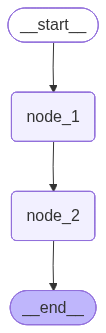

In [21]:
# View
display(Image(graph.get_graph().draw_mermaid_png()))

#### Graph Invocation

In [22]:
graph.invoke({"prompt" : "Hi"})

Node 1: State {'prompt': 'Hi'}
Node 2: State {'prompt': 'Hiand I am an AI Product Engineer'}


{'prompt': 'Hiand I am an AI Product EngineerNICE!'}

invoke runs the entire graph synchronously

### Task: In Nodes use LLM - GoogleChatModel in Langchain

In [23]:
!pip install -q -U langchain
!pip install -q -U langchain-google-genai

In [25]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GEMINI_API_KEY"] = os.getenv("GEMINI_API_KEY")

In [27]:
from langchain_google_genai import ChatGoogleGenerativeAI

# Initialize and instance of the Chat Google Generative AI with specific parameters
llm: ChatGoogleGenerativeAI = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
)

In [28]:
# Import the AIMessage class currently will be used for typing
from langchain_core.messages.ai import AIMessage

ai_msg: AIMessage = llm.invoke("HI!")

In [29]:
print(ai_msg.content)
print(type(ai_msg))

Hi there! How can I help you today?
<class 'langchain_core.messages.ai.AIMessage'>


In [30]:
from typing_extensions import TypedDict

class FirstLlmAgentCall(TypedDict):
    prompt: str
    output: str

In [31]:
def node_1(state: FirstLlmAgentCall):
    print("Node 1", state)
    prompt = state['prompt']
    ai_msg: AIMessage = llm.invoke(prompt)
    return {"output": ai_msg.content}

In [32]:
moiz_greet_message = node_1(FirstLlmAgentCall(prompt = "Hello, I'm Moiz from Islamabad"))
print(moiz_greet_message)

Node 1 {'prompt': "Hello, I'm Moiz from Islamabad"}
{'output': "Hello Moiz! It's nice to meet you. Islamabad is a beautiful city.\n\nHow can I help you today?"}


##### Now LangGraph

In [33]:
from IPython.display import Image, display
from langgraph .graph import StateGraph, START, END
from langgraph.graph.state import CompiledStateGraph #type

#Build Graph
builder: StateGraph = StateGraph(state_schema = FirstLlmAgentCall)

#Define Nodes
builder.add_node("node_1", node_1)

#Add Edges
builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)

#Compile Graph
graph: CompiledStateGraph = builder.compile()

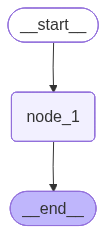

In [34]:
# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [36]:
result = graph.invoke({"prompt": "Give me actual reason why langgraph and MCP is enough to make a strong saas application? is it actually enought or not? Forget about backend dev which I have done with python and fastapi, and frontend in reaact"})

Node 1 {'prompt': 'Give me actual reason why langgraph and MCP is enough to make a strong saas application? is it actually enought or not? Forget about backend dev which I have done with python and fastapi, and frontend in reaact'}


In [37]:
print(result)

{'prompt': 'Give me actual reason why langgraph and MCP is enough to make a strong saas application? is it actually enought or not? Forget about backend dev which I have done with python and fastapi, and frontend in reaact', 'output': 'Let\'s break this down. The short answer is: **No, not by themselves in isolation.**\n\nHowever, the longer, more nuanced answer is: **Yes, absolutely, when integrated as key components within a well-architected system (which your FastAPI/React setup provides).**\n\nYou\'ve smartly excluded the general backend (FastAPI) and frontend (React) because those are the foundational layers. Langgraph and "MCP" (I\'ll interpret this as **Managed Cloud Platform/Infrastructure**) fit *into* that existing structure to provide specific, powerful capabilities crucial for a "strong SaaS."\n\nHere\'s an actual breakdown of *why* Langgraph and a robust Cloud Platform are "enough" for their respective roles within a strong SaaS, and where their strengths lie:\n\n---\n\n##

In [38]:
# Just another helper function to view response better
import textwrap
from IPython.display import display, Markdown

def to_markdown(text) -> Markdown:
    text: str = text.replace(".", " *")
    return Markdown(textwrap.indent(text, "> ", predicate = lambda _: True))

In [39]:
print("PROMPT: ", result['prompt'])
to_markdown(result['output'])

PROMPT:  Give me actual reason why langgraph and MCP is enough to make a strong saas application? is it actually enought or not? Forget about backend dev which I have done with python and fastapi, and frontend in reaact


> Let's break this down * The short answer is: **No, not by themselves in isolation ***
> 
> However, the longer, more nuanced answer is: **Yes, absolutely, when integrated as key components within a well-architected system (which your FastAPI/React setup provides) ***
> 
> You've smartly excluded the general backend (FastAPI) and frontend (React) because those are the foundational layers * Langgraph and "MCP" (I'll interpret this as **Managed Cloud Platform/Infrastructure**) fit *into* that existing structure to provide specific, powerful capabilities crucial for a "strong SaaS *"
> 
> Here's an actual breakdown of *why* Langgraph and a robust Cloud Platform are "enough" for their respective roles within a strong SaaS, and where their strengths lie:
> 
> ---
> 
> ### 1 * Langgraph: The Brain for Complex AI Workflows
> 
> Langgraph isn't just a library; it's a paradigm for building stateful, multi-step, and agentic AI applications *
> 
> **Why Langgraph is "Enough" for its Domain (Complex LLM Interactions):**
> 
> 1 *  **Robust State Management:**
>     *   **Actual Reason:** Traditional LLM chains are often stateless or manage state poorly * Langgraph excels at maintaining conversation history, intermediate results, and tool outputs across multiple steps, even in complex, branching workflows * This is critical for sophisticated AI assistants, content generation pipelines, or data analysis agents where context needs to persist and evolve *
>     *   **SaaS Benefit:** Enables highly personalized and coherent AI experiences * Users won't feel like the AI "forgets" what just happened, leading to higher engagement and satisfaction *
> 
> 2 *  **Complex Tool Orchestration and Agentic Behavior:**
>     *   **Actual Reason:** Langgraph allows you to define a graph of nodes, where each node can be an LLM call, a custom function, an external API call (a "tool"), or a conditional router * This enables true "agentic" behavior where the AI can decide *which tool to use, when, and based on what information* * It supports cycles, meaning an agent can retry, refine, or seek more information *
>     *   **SaaS Benefit:** Your AI features can perform much more complex tasks than simple prompt-response * Think AI that can search your internal database, call an external CRM API, summarize the results, and then draft an email – all autonomously within a single user request * This unlocks powerful automation and new product capabilities *
> 
> 3 *  **Error Handling and Resilience:**
>     *   **Actual Reason:** By defining explicit states and transitions, Langgraph makes it easier to implement robust error handling, retries, and fallback mechanisms within your AI workflows * If an LLM call fails or a tool returns an error, the graph can be designed to gracefully recover or inform the user, rather than crashing *
>     *   **SaaS Benefit:** Ensures your AI features are reliable and don't break easily * A stable AI experience is crucial for user trust and retention *
> 
> 4 *  **Modularity and Reusability:**
>     *   **Actual Reason:** Graphs are inherently modular * You can define sub-graphs, nodes, and tools independently and compose them * This makes your AI logic easier to develop, test, and maintain *
>     *   **SaaS Benefit:** Speeds up development of new AI features, reduces technical debt, and allows for consistent AI behavior across different parts of your application *
> 
> 5 *  **Observability and Debugging:**
>     *   **Actual Reason:** The graph structure provides a clear visual representation of the AI's decision-making process * Tools like Langsmith (which integrates well with Langchain/Langgraph) provide detailed traces of execution, showing exactly which nodes were visited, what inputs/outputs were processed, and where errors occurred *
>     *   **SaaS Benefit:** Crucial for understanding why your AI behaved a certain way, optimizing performance, and quickly troubleshooting issues in production *
> 
> ---
> 
> ### 2 * MCP (Managed Cloud Platform/Infrastructure): The Foundation for Scalability, Reliability, and Security
> 
> By "MCP," I'm assuming you mean utilizing a robust cloud provider (AWS, Azure, GCP, DigitalOcean, Render, etc *) with their managed services * This is the **operational backbone** of your SaaS *
> 
> **Why a Robust Cloud Platform is "Enough" for its Domain (Infrastructure & Operations):**
> 
> 1 *  **Scalability (Compute & Data):**
>     *   **Actual Reason:** Cloud platforms offer elastic compute (VMs, containers, serverless functions) and managed databases (PostgreSQL, MongoDB, etc *) that can scale horizontally and vertically on demand * This means your FastAPI application and its underlying data stores can handle fluctuating user loads from 10 to 10 million without manual intervention *
>     *   **SaaS Benefit:** Your application won't buckle under success * You can grow your user base without constantly re-architecting your infrastructure, ensuring a smooth experience for all users *
> 
> 2 *  **Reliability and High Availability:**
>     *   **Actual Reason:** Cloud providers build their services with redundancy, disaster recovery, and global distribution in mind * Managed services often come with high uptime SLAs (e *g *, 99 *9% or 99 *99%) * Features like load balancing, auto-scaling groups, and multi-region deployments ensure your service remains accessible even if components fail *
>     *   **SaaS Benefit:** Minimizes downtime, which is critical for user trust and revenue * Your users expect your application to *just work*, all the time *
> 
> 3 *  **Security and Compliance:**
>     *   **Actual Reason:** Cloud platforms provide a vast array of security features: network firewalls, identity and access management (IAM), encryption at rest and in transit, DDoS protection, security monitoring, and compliance certifications (SOC 2, ISO 27001, HIPAA, GDPR) * They handle much of the underlying infrastructure security *
>     *   **SaaS Benefit:** Protects sensitive user data, ensures compliance with regulations, and builds user confidence * Security breaches can be fatal for a SaaS *
> 
> 4 *  **Managed Services (Databases, Queues, Caching, etc *):**
>     *   **Actual Reason:** Instead of setting up and maintaining your own PostgreSQL server, Redis cache, or message queue (like RabbitMQ), you can use fully managed services * The cloud provider handles patching, backups, scaling, and operational overhead *
>     *   **SaaS Benefit:** Dramatically reduces operational burden and cost for your engineering team * They can focus on building product features (like those powered by Langgraph) rather than infrastructure plumbing *
> 
> 5 *  **Global Reach and Performance:**
>     *   **Actual Reason:** Cloud platforms have data centers worldwide * You can deploy your application closer to your users, reducing latency and improving perceived performance * CDN services further accelerate content delivery *
>     *   **SaaS Benefit:** Provides a fast, responsive experience for users no matter where they are, enhancing user satisfaction and potentially expanding your market *
> 
> 6 *  **Cost Efficiency (Pay-as-you-go):**
>     *   **Actual Reason:** You only pay for the resources you consume * This eliminates large upfront capital expenditures and allows you to optimize costs as your usage fluctuates *
>     *   **SaaS Benefit:** Better financial management and flexibility, especially important for startups or during periods of variable growth *
> 
> ---
> 
> ### Conclusion: Are they "Enough"?
> 
> **Yes, when combined with your FastAPI backend and React frontend, Langgraph and a robust Cloud Platform are absolutely "enough" to build a strong SaaS application ***
> 
> *   Your **FastAPI backend** provides the core business logic, API endpoints, authentication, and acts as the orchestrator between your React frontend, your database, and your Langgraph-powered AI services *
> *   Your **React frontend** delivers the user experience *
> *   **Langgraph** provides the sophisticated, scalable, and robust "brain" for any complex AI features within your SaaS *
> *   The **Managed Cloud Platform** provides the enterprise-grade foundation for everything to run securely, reliably, and at scale *
> 
> Neither Langgraph nor the Cloud Platform solve *all* problems of a SaaS in isolation, but they are *highly effective and sufficient tools for their specific domains* within the larger SaaS ecosystem you're describing * They enable you to build cutting-edge AI features and deliver them reliably to a global audience *